# Prompt 4B3 - Beat-Probability Residual Shrinkage

All results are adaptive Development evidence. IID stayed closed. No final model was selected or frozen.

## Scientific question

Global prediction is already strong, and the frozen residual correction has real Tail signal. Tail membership is not the same as correction Benefit. Prompt 4B2 Benefit regression ranked Benefit weakly. Prompt 4B3 changes only the routing target and shrinkage policy; the Global prediction and residual proposal stay frozen.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
REPORTS = ROOT / 'outputs/reports'
FIGURES = ROOT / 'outputs/figures/prompt4b3'

## Frozen design and handoff

In [2]:
design = json.loads((REPORTS / 'prompt4b3_design_freeze.json').read_text())
handoff = json.loads((REPORTS / 'prompt4b3_handoff_validation.json').read_text())
display(pd.DataFrame([{'handoff_status': handoff['status'], 'train_rows': handoff['train_rows'], 'validation_rows': handoff['validation_rows'], 'feature_count': handoff['feature_count'], 'raw_accesses': handoff['raw_access_count'], 'iid_accesses': handoff['iid_feature_access_count'] + handoff['iid_target_access_count']}]))

,handoff_status,train_rows,validation_rows,feature_count,raw_accesses,iid_accesses
0,PASS,400000,100000,37,0,0


## Beat target and existing score baselines

Beat is one only when the frozen correction reduces absolute error. A zero Benefit is labeled zero. Existing scores are compared on this same target; PR-AUC is not compared with earlier Spearman correlation.

,status,created_at_utc,rows,positive_count,negative_or_zero_count,zero_count,positive_prevalence,row_hash_digest,benefit_formula,benefit_formula_maximum_absolute_discrepancy,strict_positive_target,zero_benefit_label
0,PASS,2026-08-07T03:02:29.508644+00:00,400000,80196,319804,1789,0.20049,26265d75d8fa35d7417e2a9fb2888b9f625e6d19123cd7...,abs(y-global_oof)-abs(y-(global_oof+residual_p...,0.0,True,0


,score_id,roc_auc,pr_auc_average_precision,precision,recall,mean_realized_benefit,lift_over_base_prevalence
3,old_tail_gate,0.693926,0.341923,0.427571,0.216164,-6.535520,2.161635
8,meta_gate,0.688599,0.339023,0.425429,0.215080,-6.951845,2.150802
13,benefit_router,0.721449,0.363961,0.432000,0.218402,-5.460225,2.184024


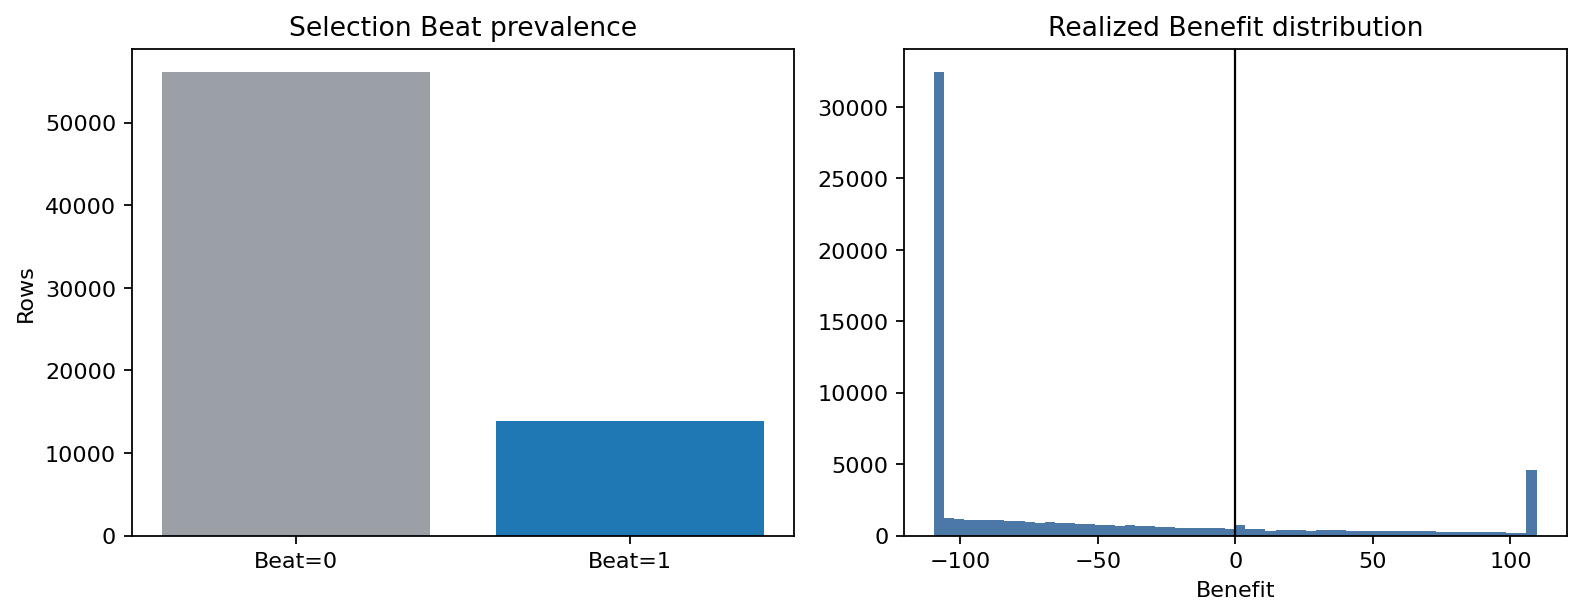

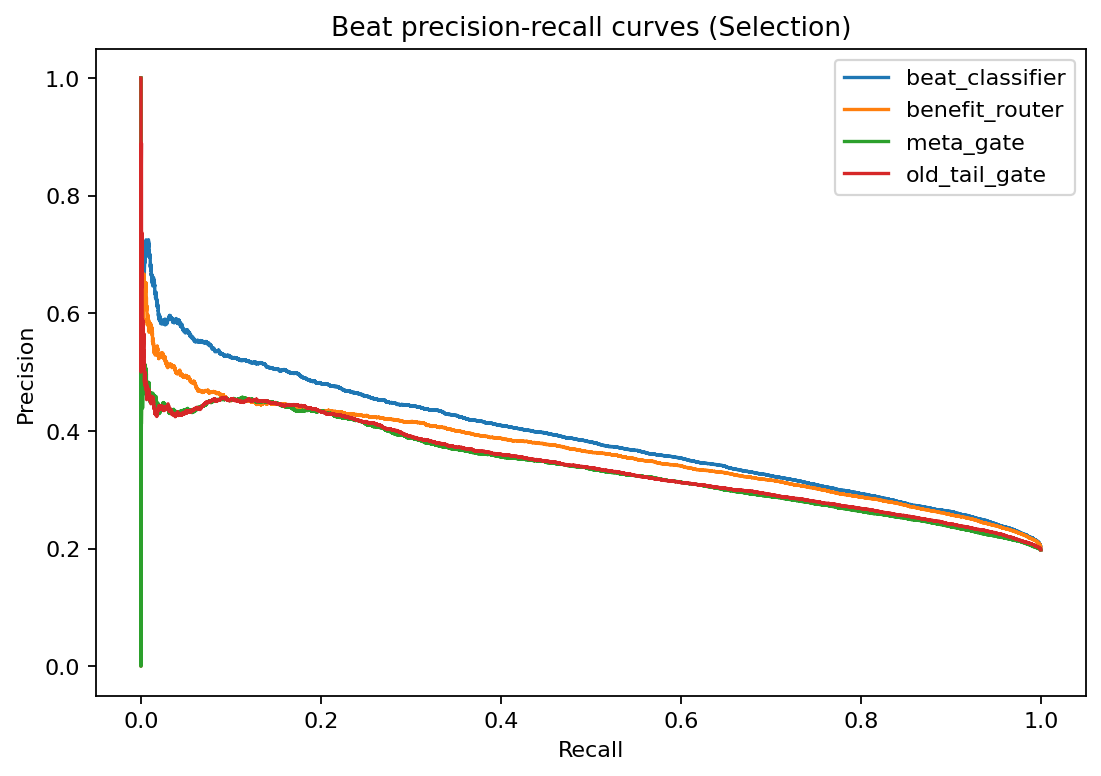

In [3]:
audit = json.loads((REPORTS / 'prompt4b3_beat_target_audit.json').read_text())
baselines = pd.read_csv(REPORTS / 'prompt4b3_zero_fit_beat_baselines.csv')
display(pd.DataFrame([audit]))
display(baselines.loc[baselines['routed_fraction'].eq(0.10), ['score_id','roc_auc','pr_auc_average_precision','precision','recall','mean_realized_benefit','lift_over_base_prevalence']])
display(Image(filename=str(FIGURES / '01_beat_prevalence_benefit_distribution.png')))
display(Image(filename=str(FIGURES / '02_beat_pr_curves.png')))

## Beat classifier diagnostics and hard gate

The classifier score is probability-like, but perfect calibration is not assumed. Policies are evaluated only if both frozen diagnostic conditions pass.

,scope,rows,beat_positive_count,beat_prevalence,roc_auc,pr_auc_average_precision,brier_score,log_loss
0,selection,70000.0,13846.0,0.197800,0.733304,0.389680,0.141156,0.439860
1,audit_descriptive,30000.0,6004.0,0.200133,0.731309,0.388707,0.142673,0.443850
2,complete_validation_descriptive,100000.0,19850.0,0.198500,0.732699,0.389296,0.141611,0.441057


,DG1,DG1_lower,DG2,new_top10_benefit,best_existing_top10_benefit,policy_evaluation
0,True,0.022289,True,-5.402976,-5.460225,True


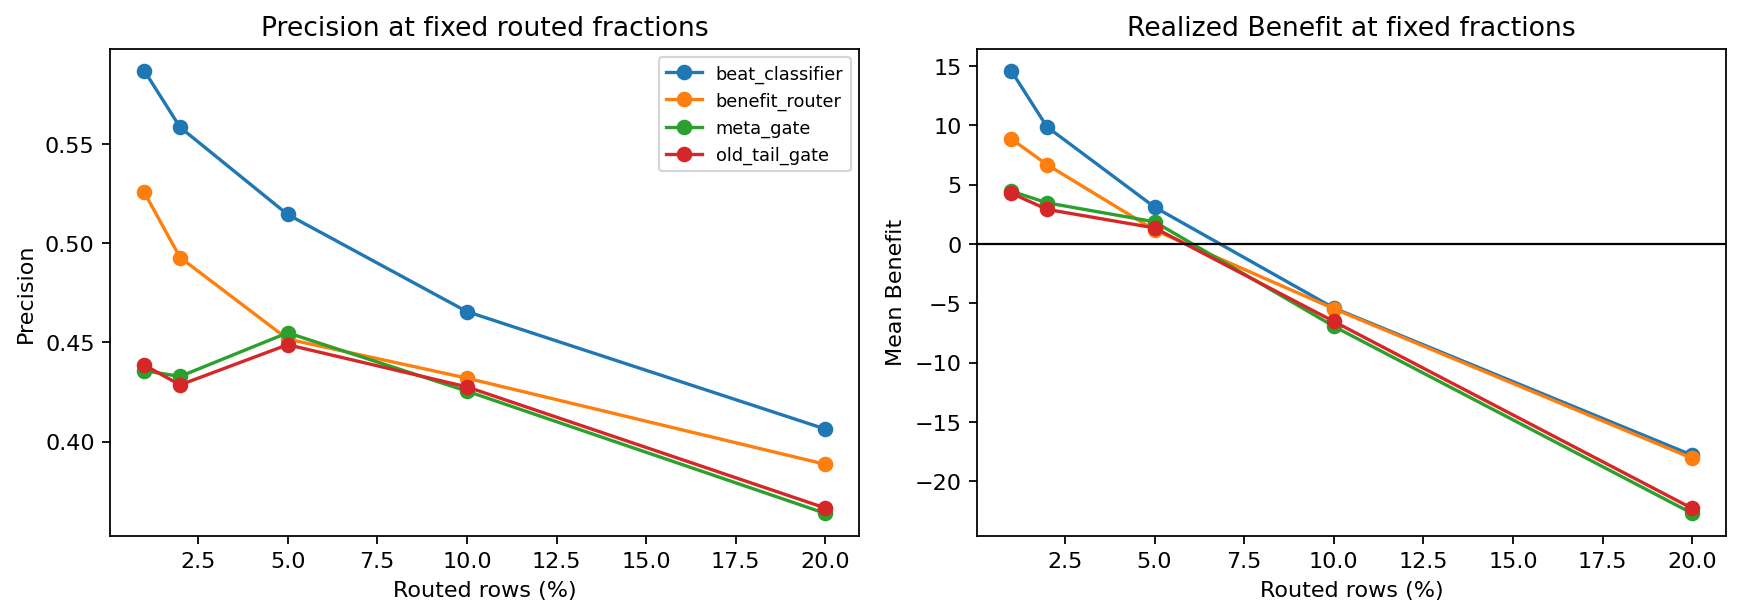

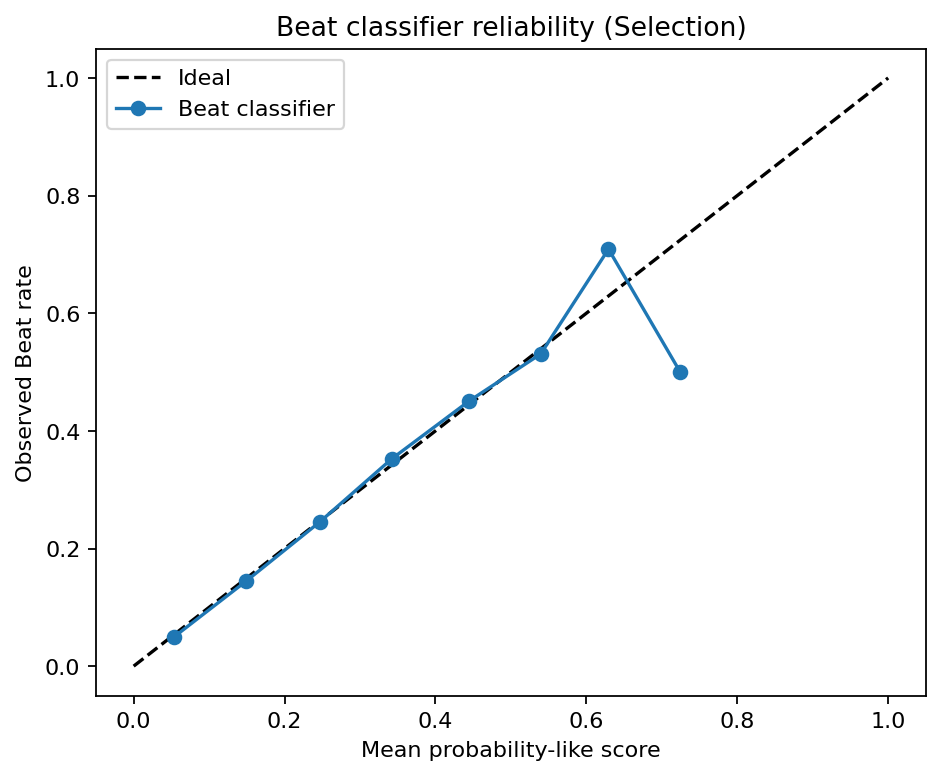

In [4]:
diagnostics = json.loads((REPORTS / 'prompt4b3_classifier_diagnostics.json').read_text())
gate = json.loads((REPORTS / 'prompt4b3_diagnostic_gate.json').read_text())
display(pd.DataFrame(diagnostics['scopes']).T.reset_index(names='scope'))
display(pd.DataFrame([{'DG1': gate['DG1']['pass'], 'DG1_lower': gate['DG1']['percentile_2_5'], 'DG2': gate['DG2']['pass'], 'new_top10_benefit': gate['DG2']['new_top_10_mean_realized_benefit'], 'best_existing_top10_benefit': gate['DG2']['best_existing_top_10_mean_realized_benefit'], 'policy_evaluation': gate['policy_evaluation_authorized']}]))
display(Image(filename=str(FIGURES / '03_fixed_fraction_precision_benefit.png')))
display(Image(filename=str(FIGURES / '04_classifier_reliability.png')))

## Two frozen shrinkage policies

Both policies use the same classifier score and unchanged residual proposal. Policy B uses Train-OOF `p0` as a cost-informed pre-frozen rule, not as a perfect Bayesian threshold.

,candidate_id,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,mean_signed_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
0,prompt4b3__beat_linear,selection,70000,63.992247,126.609641,0.697790,0.407216,39.072450,135.005749,11.225034,...,0.355930,False,True,False,True,True,True,4,6,PARTIAL
1,prompt4b3__beat_linear,audit_descriptive,30000,63.570524,119.563931,0.703928,0.406209,38.954666,136.369705,11.027319,...,0.354636,False,True,False,True,True,True,4,6,PARTIAL
2,prompt4b3__beat_linear,complete_validation_descriptive,100000,63.865730,124.537789,0.699514,0.406914,39.030769,135.329072,11.165720,...,0.355542,False,True,False,True,True,True,4,6,PARTIAL
3,prompt4b3__beat_costaware,selection,70000,62.501388,127.419488,0.693911,0.390853,36.920612,132.097442,-8.920908,...,0.476118,True,False,True,True,True,True,5,6,PARTIAL
4,prompt4b3__beat_costaware,audit_descriptive,30000,61.959450,120.301166,0.700266,0.390656,36.476511,133.814173,-9.118698,...,0.474119,True,False,True,True,True,True,5,6,PARTIAL
5,prompt4b3__beat_costaware,complete_validation_descriptive,100000,62.338807,125.326451,0.695696,0.390794,36.819171,132.771876,-8.980245,...,0.475518,True,False,True,True,True,True,5,6,PARTIAL


,candidate_id,scope,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
0,prompt4b3__beat_linear,selection,False,True,False,True,True,True,4,6,PARTIAL
1,prompt4b3__beat_linear,audit_descriptive,False,True,False,True,True,True,4,6,PARTIAL
2,prompt4b3__beat_linear,complete_validation_descriptive,False,True,False,True,True,True,4,6,PARTIAL
3,prompt4b3__beat_costaware,selection,True,False,True,True,True,True,5,6,PARTIAL
4,prompt4b3__beat_costaware,audit_descriptive,True,False,True,True,True,True,5,6,PARTIAL
5,prompt4b3__beat_costaware,complete_validation_descriptive,True,False,True,True,True,True,5,6,PARTIAL


,experimental_champion,selection_only,final_project_model
0,prompt4b3__beat_costaware,True,False


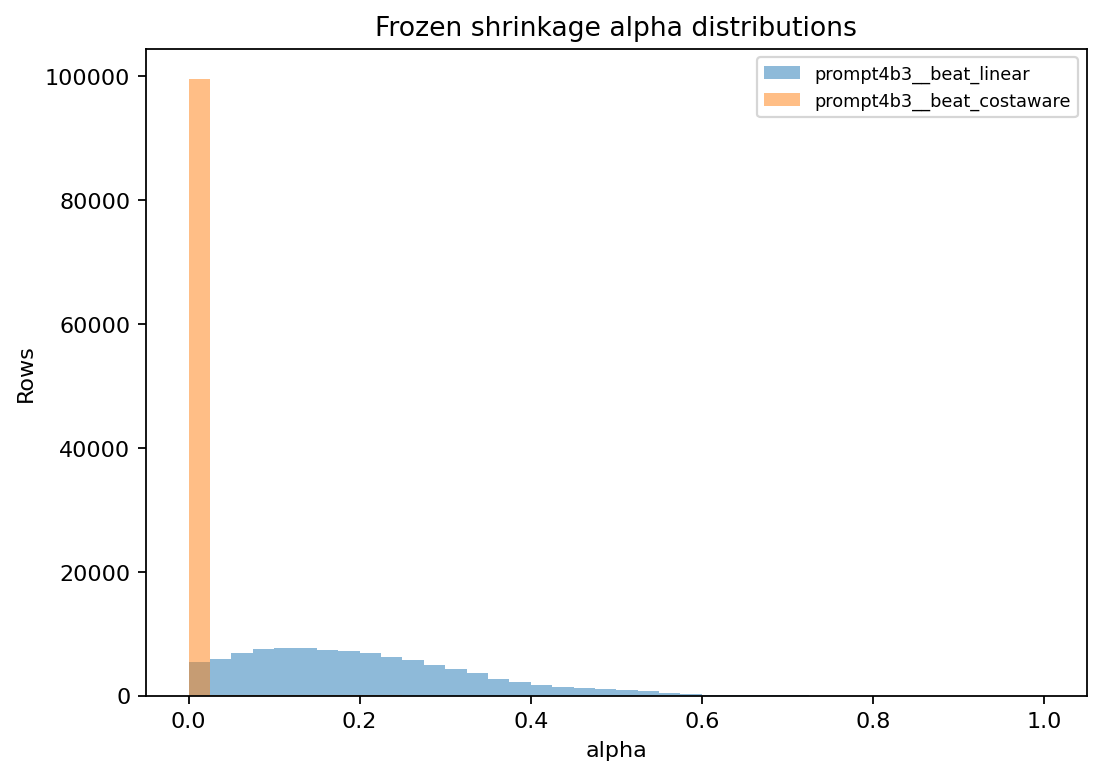

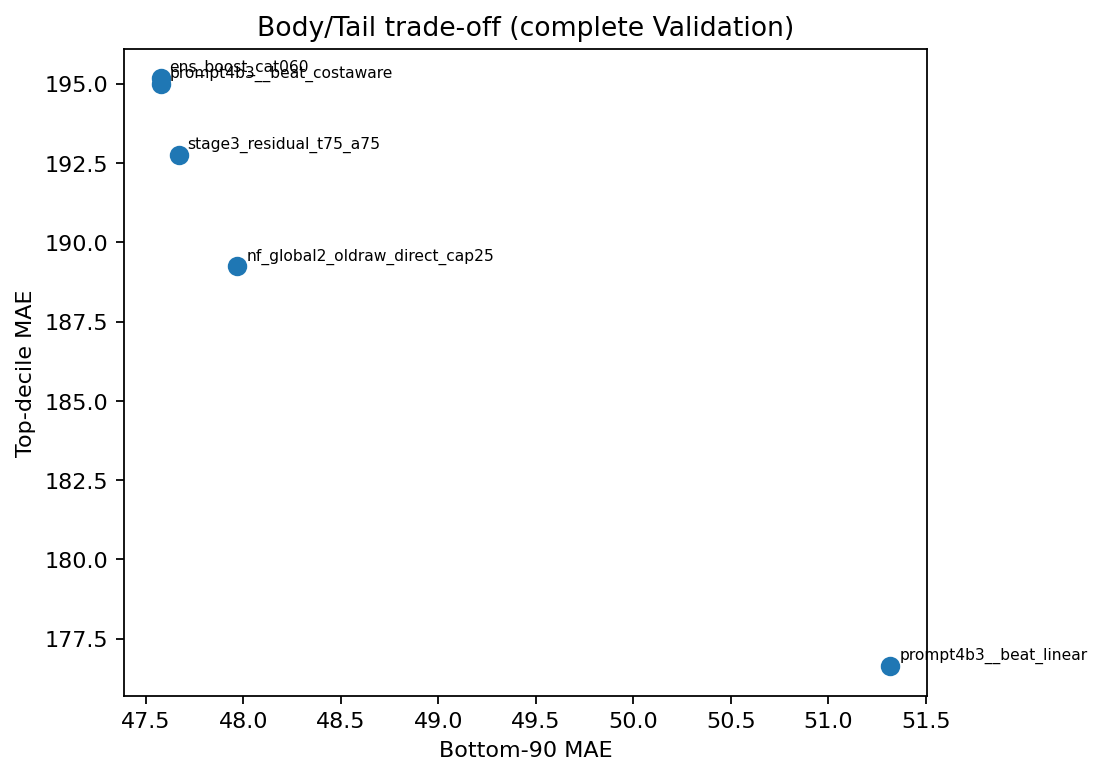

In [5]:
policies = pd.read_csv(REPORTS / 'prompt4b3_policy_results.csv')
six = pd.read_csv(REPORTS / 'prompt4b3_six_condition_results.csv')
champion = json.loads((REPORTS / 'prompt4b3_experimental_champion.json').read_text())
display(policies)
display(six)
display(pd.DataFrame([{'experimental_champion': champion['candidate_id'], 'selection_only': champion['selection_only'], 'final_project_model': champion['final_project_model']}]))
display(Image(filename=str(FIGURES / '05_alpha_distributions.png')))
display(Image(filename=str(FIGURES / '06_body_tail_tradeoff.png')))

## Adaptive Development bootstrap

This paired bootstrap is descriptive. It does not repair adaptive-selection bias.

In [6]:
display(pd.read_csv(REPORTS / 'prompt4b3_bootstrap.csv'))

,reference_id,metric,rows,difference_champion_minus_reference,percentile_2_5,median,percentile_97_5,resamples,seed,label
0,ens_boost_cat060,overall_mae_difference,100000,-0.017509,-0.022457,-0.017455,-0.012068,500,42,adaptive Development descriptive bootstrap
1,ens_boost_cat060,fixed_top_decile_mae_difference,10013,-0.178248,-0.226017,-0.176460,-0.131864,500,42,adaptive Development descriptive bootstrap
2,stage3_residual_t75_a75,overall_mae_difference,100000,0.142150,0.071086,0.142324,0.217585,500,42,adaptive Development descriptive bootstrap
3,stage3_residual_t75_a75,fixed_top_decile_mae_difference,10013,2.243463,1.573276,2.247175,2.920921,500,42,adaptive Development descriptive bootstrap
4,nf_global2_oldraw_direct_cap25,overall_mae_difference,100000,0.224068,0.159950,0.223036,0.285982,500,42,adaptive Development descriptive bootstrap
5,nf_global2_oldraw_direct_cap25,fixed_top_decile_mae_difference,10013,5.764948,5.248385,5.798309,6.309726,500,42,adaptive Development descriptive bootstrap


## Cross-stage context

In [7]:
display(pd.read_csv(REPORTS / 'prompt4b3_cross_stage_comparison.csv'))

,reference,candidate_id,selection_mae,audit_mae,complete_validation_mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,top_decile_signed_error,top_decile_underprediction_rate,conditions_passed,status
0,Global,ens_boost_cat060,62.519519,61.975508,62.356316,125.418232,47.576966,195.178575,279.352393,-139.054319,0.793968,0,REFERENCE
1,Prompt 4B Stage 3,stage3_residual_t75_a75,62.352823,61.832268,62.196656,123.038499,47.669010,192.756864,272.424700,-127.335474,0.777290,5,PARTIAL
2,Block A,nf_global2_oldraw_direct_cap25,62.249933,61.799286,62.114739,124.433887,47.969818,189.235379,266.861715,-125.803946,0.761710,5,PARTIAL
3,Block B,quantile_q60_meta_symmetric,62.446862,61.931244,62.292177,121.838785,47.770520,192.798549,269.714016,-112.280671,0.759013,4,PARTIAL
4,Block C,benefit_b0,62.375994,61.894181,62.231450,124.382868,47.688426,192.929848,272.367190,-127.857456,0.775392,5,PARTIAL
5,Prompt 4B3 policy,prompt4b3__beat_linear,63.992247,63.570524,63.865730,124.537789,51.317767,176.634486,258.194021,-107.677504,0.732448,4,PARTIAL
6,Prompt 4B3 policy,prompt4b3__beat_costaware,62.501388,61.959450,62.338807,125.326451,47.577343,195.000327,278.993075,-138.661834,0.793369,5,PARTIAL


## Boundary

The result is adaptive Development evidence. IID remains completely unopened. No final project model was selected or frozen, and Prompt 4C was not executed. Human review is the next step.